<a href="https://colab.research.google.com/github/J4m331/COMP3608-IS-Project/blob/Create-Decision-Tree-Folder/decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install -U scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 21.3 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [2]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

In [3]:
url1 = "https://raw.githubusercontent.com/J4m331/COMP3608-IS-Project/refs/heads/Create-Decision-Tree-Folder/data/vgData2024.csv"
Dataset1 = pd.read_csv(url1, header=0)

url2 = "https://raw.githubusercontent.com/J4m331/COMP3608-IS-Project/refs/heads/main/data/vgData2026.csv"
Dataset2 = pd.read_csv(url2, header=0)

In [19]:
Columns_neededc= ["Name","Publisher","Platform","Genre","Release_Year","NA_Sales","EU_Sales","JP_Sales","Other_Sales"]

Dataset1 = Dataset1[Columns_needed]
Dataset2 = Dataset2[Columns_needed]


In [20]:
Combined_Dataset = pd.concat([Dataset1, Dataset2], ignore_index=True)
Combined_Dataset = Combined_Dataset.drop_duplicates(subset = 'Name')

Combined_Dataset['Release_Year'] = pd.to_datetime(Combined_Dataset['Release_Year'], errors = 'coerce').dt.year
mean_release_year = Combined_Dataset['Release_Year'].mean()
Combined_Dataset['Release_Year'] = Combined_Dataset['Release_Year'].fillna(mean_release_year)
Combined_Dataset['Release_Year'] = Combined_Dataset['Release_Year'].astype(int)

print(f"NaN values in 'Release_Year' of Combined_Dataset after imputation: {Combined_Dataset['Release_Year'].isnull().sum()}")

Combined_Dataset.head()

NaN values in 'Release_Year' of Combined_Dataset after imputation: 0


,Name,Publisher,Platform,Genre,Release_Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales
0,'98 Koshien,Magical Company,PS,Sports,1998,0.15,0.10,0.12,0.03
1,.hack//G.U. Vol.1//Rebirth,Namco Bandai Games,PS2,Role-Playing,2006,0.00,0.00,0.17,0.00
2,.hack//G.U. Vol.2//Reminisce,Namco Bandai Games,PS2,Role-Playing,2006,0.11,0.09,0.00,0.03
3,.hack//G.U. Vol.2//Reminisce (jp sales),Namco Bandai Games,PS2,Role-Playing,2006,0.00,0.00,0.16,0.00
4,.hack//G.U. Vol.3//Redemption,Namco Bandai Games,PS2,Role-Playing,2006,0.00,0.00,0.17,0.00


In [21]:
Combined_Dataset['Total_Sales'] = (Combined_Dataset['NA_Sales']+Combined_Dataset['EU_Sales']+Combined_Dataset['JP_Sales']+Combined_Dataset['Other_Sales'])
Combined_Dataset.head()

,Name,Publisher,Platform,Genre,Release_Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Total_Sales
0,'98 Koshien,Magical Company,PS,Sports,1998,0.15,0.10,0.12,0.03,0.40
1,.hack//G.U. Vol.1//Rebirth,Namco Bandai Games,PS2,Role-Playing,2006,0.00,0.00,0.17,0.00,0.17
2,.hack//G.U. Vol.2//Reminisce,Namco Bandai Games,PS2,Role-Playing,2006,0.11,0.09,0.00,0.03,0.23
3,.hack//G.U. Vol.2//Reminisce (jp sales),Namco Bandai Games,PS2,Role-Playing,2006,0.00,0.00,0.16,0.00,0.16
4,.hack//G.U. Vol.3//Redemption,Namco Bandai Games,PS2,Role-Playing,2006,0.00,0.00,0.17,0.00,0.17


In [22]:
low_thresh = Combined_Dataset['Total_Sales'].quantile(0.33)
high_thresh = Combined_Dataset['Total_Sales'].quantile(0.66)

def classify_sales(x):
    if x <= low_thresh:
        return 'Low'
    elif x <= high_thresh:
        return 'Medium'
    else:
        return 'High'


Combined_Dataset['Sales_Category'] = Combined_Dataset['Total_Sales'].apply(classify_sales)
Combined_Dataset.head()

,Name,Publisher,Platform,Genre,Release_Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Total_Sales,Sales_Category
0,'98 Koshien,Magical Company,PS,Sports,1998,0.15,0.10,0.12,0.03,0.40,High
1,.hack//G.U. Vol.1//Rebirth,Namco Bandai Games,PS2,Role-Playing,2006,0.00,0.00,0.17,0.00,0.17,Medium
2,.hack//G.U. Vol.2//Reminisce,Namco Bandai Games,PS2,Role-Playing,2006,0.11,0.09,0.00,0.03,0.23,Medium
3,.hack//G.U. Vol.2//Reminisce (jp sales),Namco Bandai Games,PS2,Role-Playing,2006,0.00,0.00,0.16,0.00,0.16,Medium
4,.hack//G.U. Vol.3//Redemption,Namco Bandai Games,PS2,Role-Playing,2006,0.00,0.00,0.17,0.00,0.17,Medium


In [23]:
from sklearn.preprocessing import LabelEncoder

le_genre = LabelEncoder()
le_platform = LabelEncoder()
le_publisher = LabelEncoder()
le_target = LabelEncoder()

Combined_Dataset['Genre_enc'] = le_genre.fit_transform(Combined_Dataset['Genre'])
Combined_Dataset['Platform_enc'] = le_platform.fit_transform(Combined_Dataset['Platform'])
Combined_Dataset['Publisher_enc'] = le_publisher.fit_transform(Combined_Dataset['Publisher'])
Combined_Dataset['Sales_Category_enc'] = le_target.fit_transform(Combined_Dataset['Sales_Category'])

Combined_Dataset.head()

,Name,Publisher,Platform,Genre,Release_Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Total_Sales,Sales_Category,Genre_enc,Platform_enc,Publisher_enc,Sales_Category_enc
0,'98 Koshien,Magical Company,PS,Sports,1998,0.15,0.10,0.12,0.03,0.40,High,13,15,289,0
1,.hack//G.U. Vol.1//Rebirth,Namco Bandai Games,PS2,Role-Playing,2006,0.00,0.00,0.17,0.00,0.17,Medium,10,16,342,2
2,.hack//G.U. Vol.2//Reminisce,Namco Bandai Games,PS2,Role-Playing,2006,0.11,0.09,0.00,0.03,0.23,Medium,10,16,342,2
3,.hack//G.U. Vol.2//Reminisce (jp sales),Namco Bandai Games,PS2,Role-Playing,2006,0.00,0.00,0.16,0.00,0.16,Medium,10,16,342,2
4,.hack//G.U. Vol.3//Redemption,Namco Bandai Games,PS2,Role-Playing,2006,0.00,0.00,0.17,0.00,0.17,Medium,10,16,342,2


In [24]:
X = Combined_Dataset[['Genre_enc', 'Platform_enc', 'Publisher_enc', 'Release_Year']]
Y = Combined_Dataset['Sales_Category_enc']

In [25]:
X_train, X_test, Y_train, Y_test= train_test_split(X, Y, test_size=0.3, random_state=100)

In [26]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(max_depth = 5, random_state = 100)
model.fit(X_train, Y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",100
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [27]:
y_pred = model.predict(X_test)
print("Accuracy:",accuracy_score(Y_test, y_pred))
print("/nClssification Report:/n",classification_report(Y_test, y_pred))

Accuracy: 0.448021264028352
/nClssification Report:/n               precision    recall  f1-score   support

           0       0.53      0.35      0.43      1116
           1       0.51      0.46      0.48      1189
           2       0.37      0.54      0.44      1081

    accuracy                           0.45      3386
   macro avg       0.47      0.45      0.45      3386
weighted avg       0.47      0.45      0.45      3386



In [28]:
Combined_Dataset['Predicted_Class'] = model.predict(X)

Combined_Dataset['Predicted_Class_Label'] = le_target.inverse_transform(
    Combined_Dataset['Predicted_Class']
)

company_scores = Combined_Dataset.groupby('Publisher')['Predicted_Class_Label'] \
    .apply(lambda x: (x == 'High').mean())

top_10 = company_scores.sort_values(ascending=False).head(10)

print("Top 10 Companies Likely to Achieve High Sales:")
print(top_10)



Top 10 Companies Likely to Achieve High Sales:
Publisher
responDESIGN               1.0
Wizard Video Games         1.0
Accolade                   1.0
Valve                      1.0
Universal Gamex            1.0
UEP Systems                1.0
U.S. Gold                  1.0
Tryfirst                   1.0
Time Warner Interactive    1.0
Tigervision                1.0
Name: Predicted_Class_Label, dtype: float64


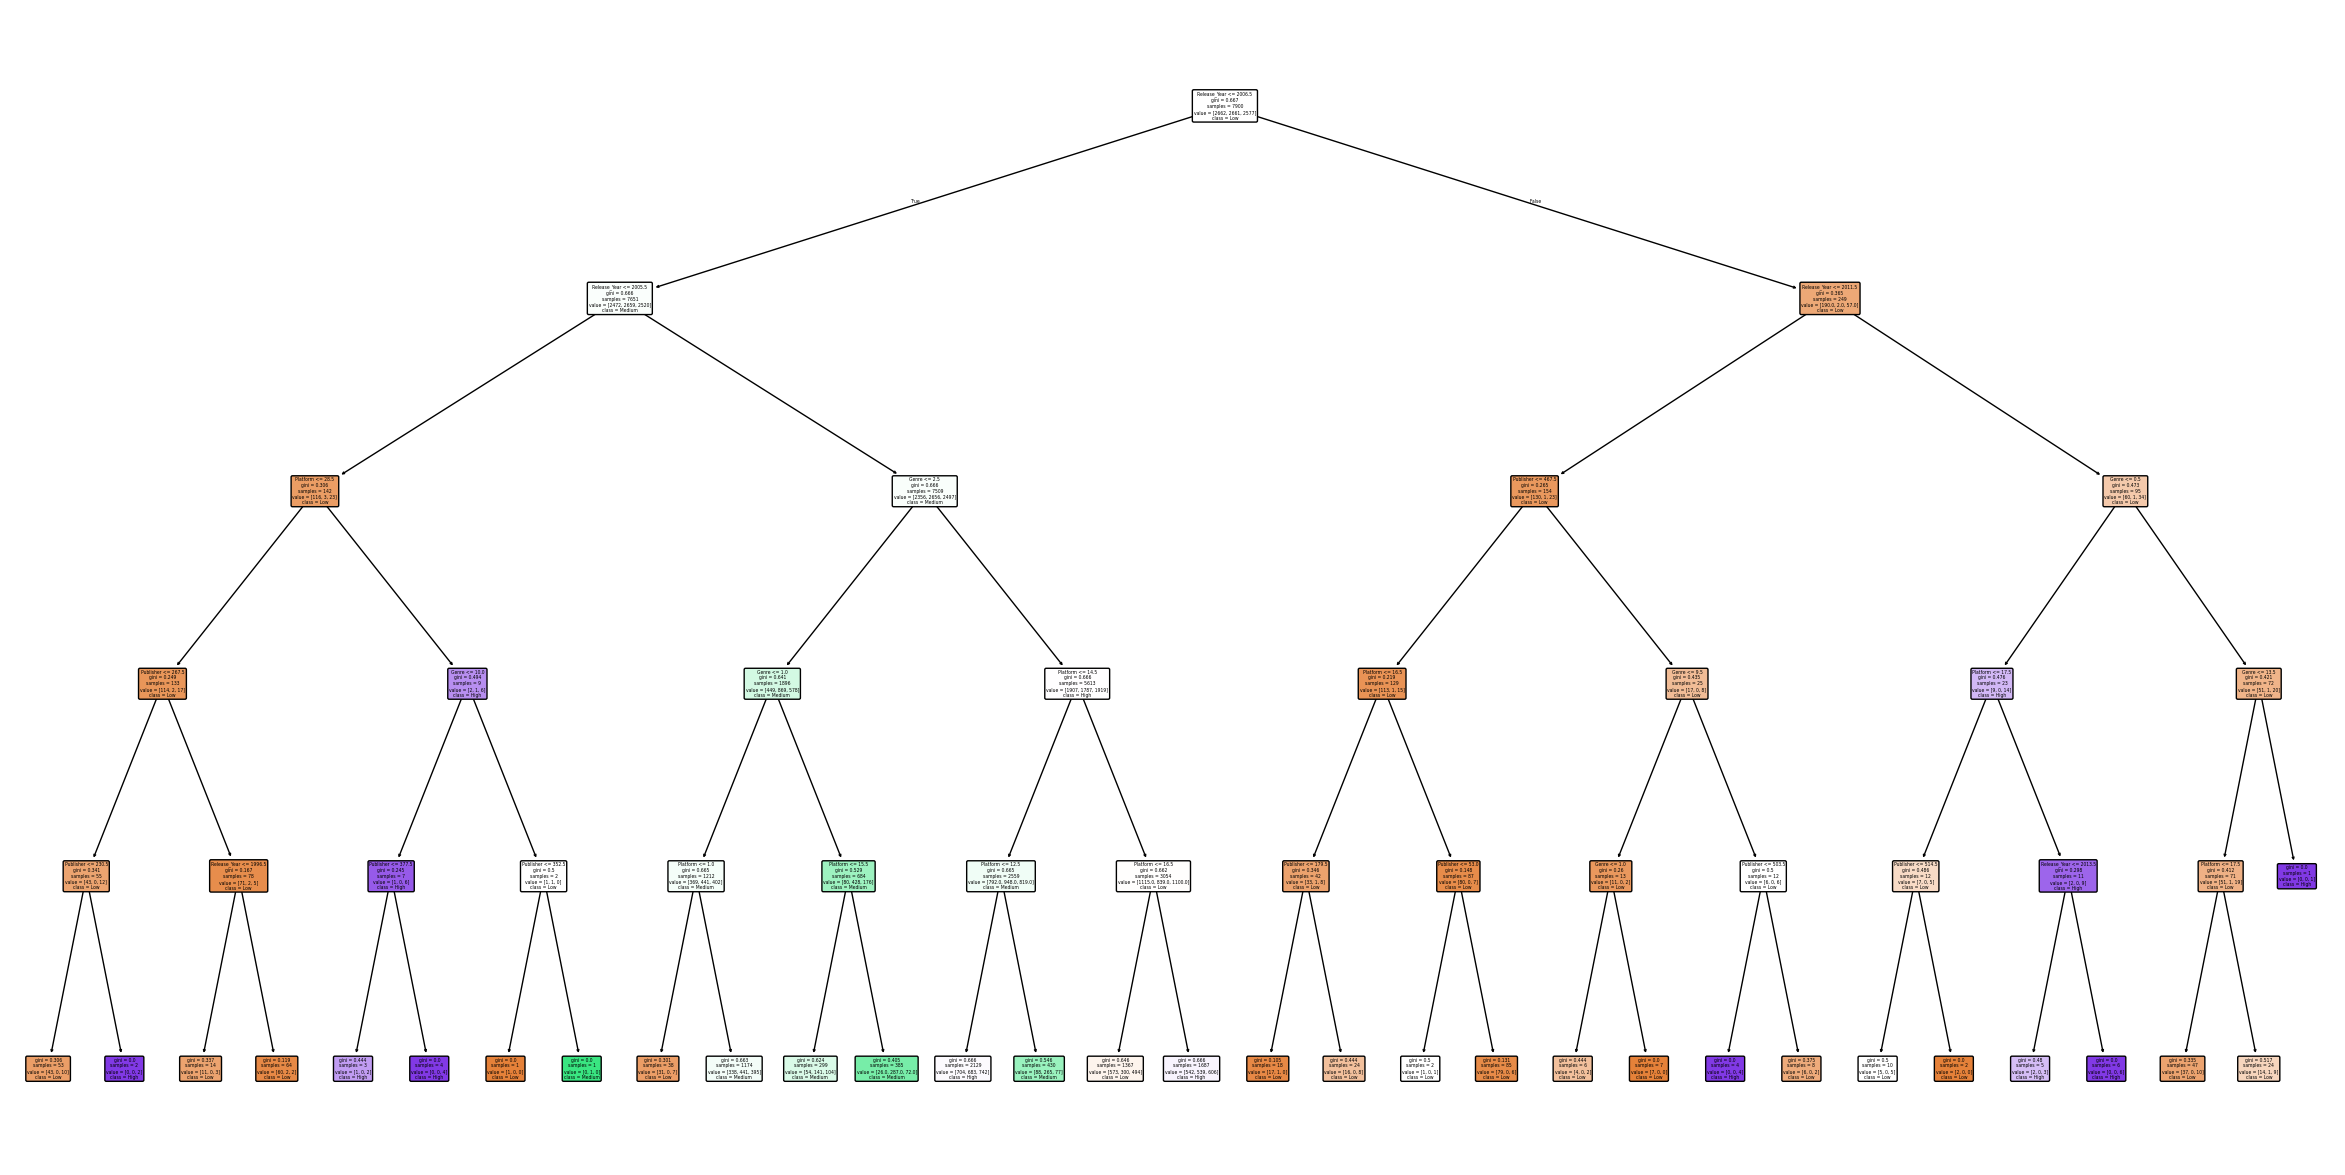

In [29]:
plt.figure(figsize=(30,15))
plot_tree(
    model,
    feature_names=['Genre', 'Platform', 'Publisher', 'Release_Year'],
    class_names=['Low', 'Medium', 'High'],
    filled=True,
    rounded=True
)
plt.show()
